# Plotting the Results From Lapitan PPG Generation

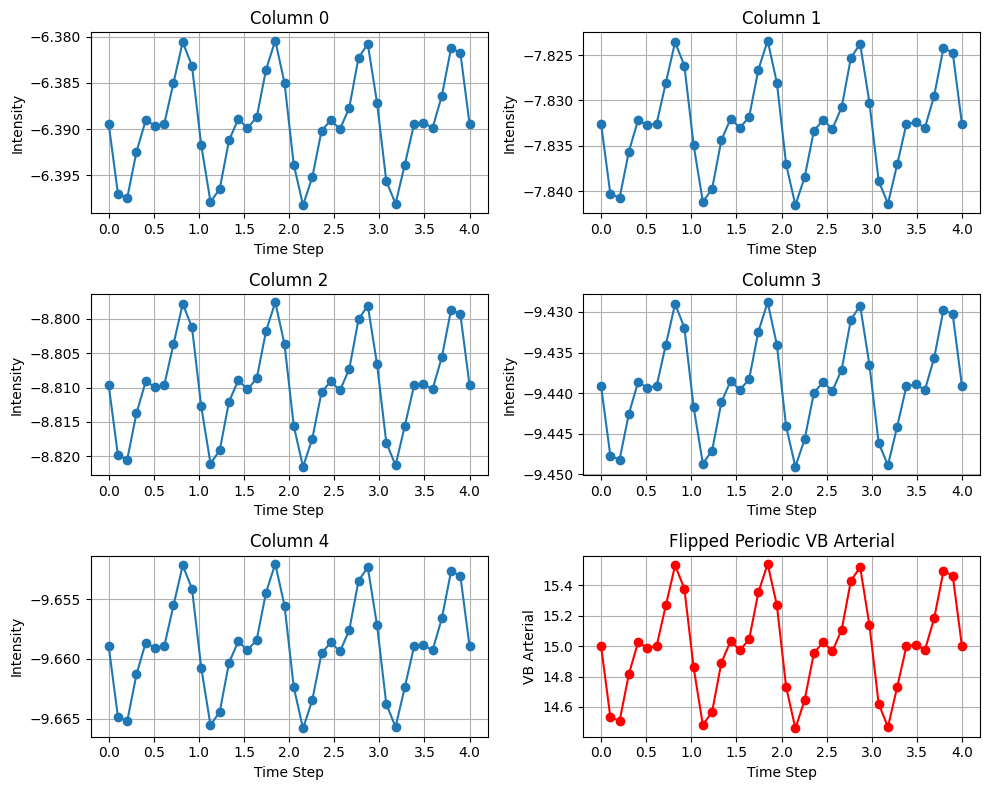

In [1]:
import sys

sys.path.append("../src")
sys.path.append("../src/tfo_sim2")

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from tfo_sim2.result_storage import ResultStorage

data_path = Path("../batch_results/dan4_single_periodic")
result_files = sorted(data_path.glob("*.npz"))
results : list[ResultStorage] = [ResultStorage.load(str(f)) for f in result_files]
detector_intensities = np.array([res.detint for res in results])

arr = detector_intensities / 1e8  # Normalize by number of photons 
time_axis = np.linspace(0, 4.0, 40)
fundamental = 0.375 * np.sin(2 * np.pi * time_axis)
harmonic = 0.375 / 1.5 * np.sin(4 * np.pi * time_axis)
periodic_vb_arterial = 15.0 + fundamental + harmonic


n_cols = arr.shape[1]
fig, axes = plt.subplots(3, 2, figsize=(10, 8))
axes = axes.flatten()

for i in range(n_cols):
    ax = axes[i]
    ax.plot(time_axis, np.log10(arr[:, i]), marker='o')
    ax.set_title(f'Column {i}')
    ax.set_xlabel('Time Step')
    ax.set_ylabel('Intensity')
    ax.grid(True)

ax = axes[-1]
flipped_periodic_vb_arterial = 15.0 - fundamental - harmonic
ax.plot(time_axis, flipped_periodic_vb_arterial, color='red', marker='o')
ax.set_title('Flipped Periodic VB Arterial')
ax.set_xlabel('Time Step')
ax.set_ylabel('VB Arterial')
ax.grid(True)


fig.tight_layout()
plt.show()

# Plotting the FFTs
Make the signals zero mean and then plot the FFT - Only look at the AC components

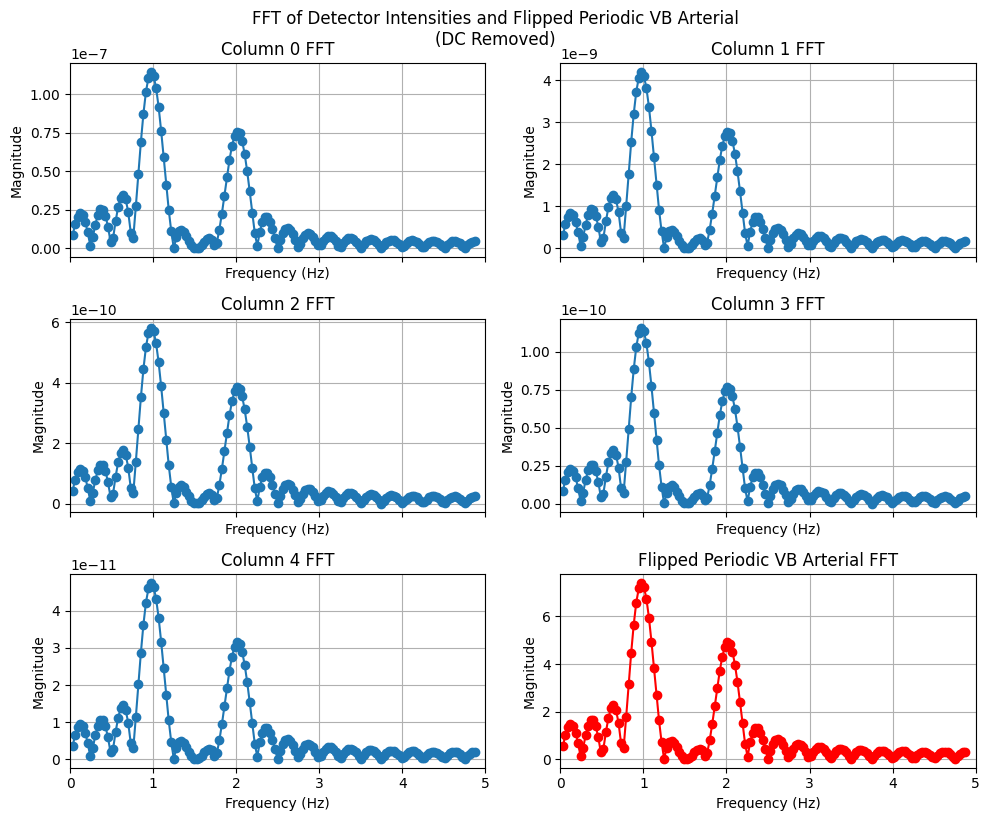

In [3]:
fig_fft, axes_fft = plt.subplots(3, 2, figsize=(10, 8), sharex=True)
axes_fft = axes_fft.flatten()
fft_point_count = len(time_axis) * 8
window = np.hanning(len(time_axis))

for i in range(n_cols):
    y = arr[:, i]
    y = y - np.mean(y)  # Make zero mean
    # y = y * window  # Apply window  
    yf = np.fft.rfft(y, n=fft_point_count)
    xf = np.fft.rfftfreq(fft_point_count, d=time_axis[1] - time_axis[0])
    axes_fft[i].plot(xf[1:], np.abs(yf[1:]), marker='o')
    axes_fft[i].set_title(f'Column {i} FFT')
    axes_fft[i].set_xlabel('Frequency (Hz)')
    axes_fft[i].set_ylabel('Magnitude')
    # axes_fft[i].set_yscale('log')
    axes_fft[i].grid(True)

ax = axes_fft[-1]
y = flipped_periodic_vb_arterial
y = y - np.mean(y)  # Make zero mean
# y = y * window  # Apply window
yf = np.fft.rfft(y, n=fft_point_count)
xf = np.fft.rfftfreq(fft_point_count, d=time_axis[1] - time_axis[0])
# ax.set_yscale('log')
ax.plot(xf[1:], np.abs(yf[1:]), color='red', marker='o')
ax.set_title('Flipped Periodic VB Arterial FFT')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Magnitude')
ax.grid(True)
plt.xlim(0, 5.0)


fig_fft.tight_layout()
plt.suptitle('FFT of Detector Intensities and Flipped Periodic VB Arterial\n(DC Removed)', y=1.02)
plt.show()

# Plotting MBLL Assuming a Straight Line Medium
Going to assume a single medium with an arbitrary epsilon and no scattering. Only check shape and FFT when comparing and ignore magnitude

/tmp/ipykernel_3314930/3822109194.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_intensity_fft[3].legend()


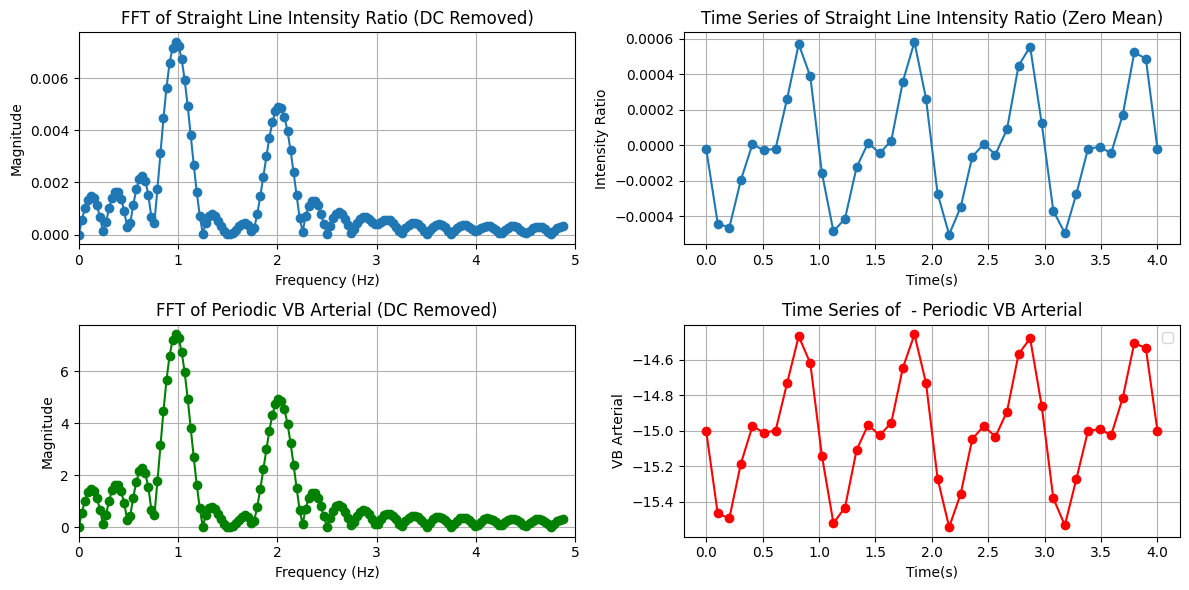

In [5]:
epsilon = 0.1
l = 4.0
intensity_ratio = np.exp(-epsilon * periodic_vb_arterial * l)
intensity_ratio = intensity_ratio - np.mean(intensity_ratio)  # Make zero mean
yf = np.fft.rfft(intensity_ratio, n=fft_point_count)
xf = np.fft.rfftfreq(fft_point_count, d=time_axis[1] - time_axis[0])


fig_intensity_fft, ax_intensity_fft = plt.subplots(2, 2, figsize=(12, 6))
ax_intensity_fft = ax_intensity_fft.flatten()

ax_intensity_fft[0].plot(xf, np.abs(yf), marker='o')
ax_intensity_fft[0].set_title('FFT of Straight Line Intensity Ratio (DC Removed)')
ax_intensity_fft[0].set_xlabel('Frequency (Hz)')
ax_intensity_fft[0].set_ylabel('Magnitude')
ax_intensity_fft[0].grid(True)
ax_intensity_fft[0].set_xlim(0, 5.0)

ax_intensity_fft[1].plot(time_axis, intensity_ratio, marker='o')
ax_intensity_fft[1].set_title('Time Series of Straight Line Intensity Ratio (Zero Mean)')
ax_intensity_fft[1].set_xlabel('Time(s)')
ax_intensity_fft[1].set_ylabel('Intensity Ratio')
ax_intensity_fft[1].grid(True)


y = periodic_vb_arterial - np.mean(periodic_vb_arterial)
yf = np.fft.rfft(y, n=fft_point_count)
xf = np.fft.rfftfreq(fft_point_count, d=time_axis[1] - time_axis[0])

ax_intensity_fft[2].plot(xf, np.abs(yf), marker='o', color='green')
ax_intensity_fft[2].set_title('FFT of Periodic VB Arterial (DC Removed)')
ax_intensity_fft[2].set_xlabel('Frequency (Hz)')
ax_intensity_fft[2].set_ylabel('Magnitude')
ax_intensity_fft[2].grid(True)
ax_intensity_fft[2].set_xlim(0, 5.0)


ax_intensity_fft[3].plot(time_axis, -periodic_vb_arterial, marker='o', color='red')
ax_intensity_fft[3].set_title('Time Series of  - Periodic VB Arterial')
ax_intensity_fft[3].set_xlabel('Time(s)')
ax_intensity_fft[3].set_ylabel('VB Arterial')
ax_intensity_fft[3].grid(True)
ax_intensity_fft[3].legend()

plt.tight_layout()
plt.show()